In [33]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [34]:
image = cv2.imread('./a.jpg')
image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

height,width = image_gray.shape

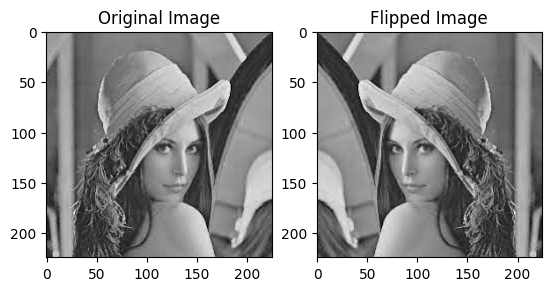

In [35]:
flipped_image = image_gray.copy()

for arr in flipped_image:
    i = 00
    j = len(arr)-1
    
    while i<j:
        temp = arr[i]
        arr[i] = arr[j]
        arr[j] = temp
        i+=1
        j-=1

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_gray, cmap='gray')

plt.subplot(1,2,2)
plt.title("Flipped Image")

plt.imshow(flipped_image, cmap='gray')


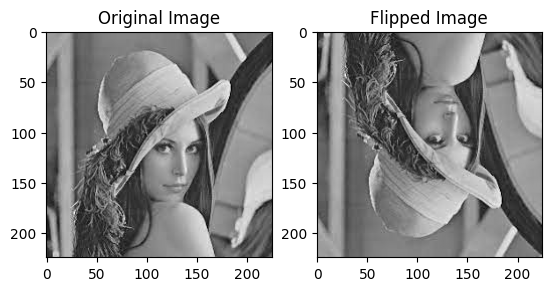

In [36]:
flippped = np.zeros((height,width))

for i in range(height):
    for j in range(width):
        flippped[i][j] = image_gray[height-i-1][j]

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_gray, cmap='gray')

plt.subplot(1,2,2)
plt.title("Flipped Image")
plt.imshow(flippped, cmap='gray')


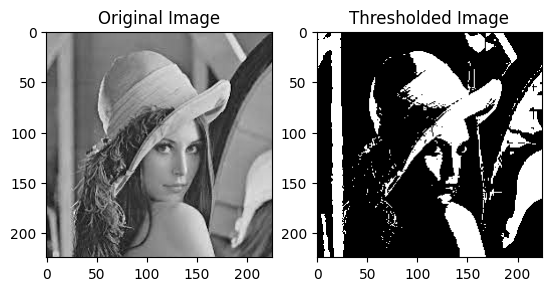

In [37]:
thresholding = np.zeros((height,width))

for i in range(height):
    for j in range(width):
        pixel = image_gray[i][j]
        if pixel < 155:
            pixel = 0
        else:
            pixel = 255
        thresholding[i][j] = pixel


plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_gray, cmap='gray')

plt.subplot(1,2,2)
plt.title("Thresholded Image")
plt.imshow(thresholding, cmap='gray')

plt.show()

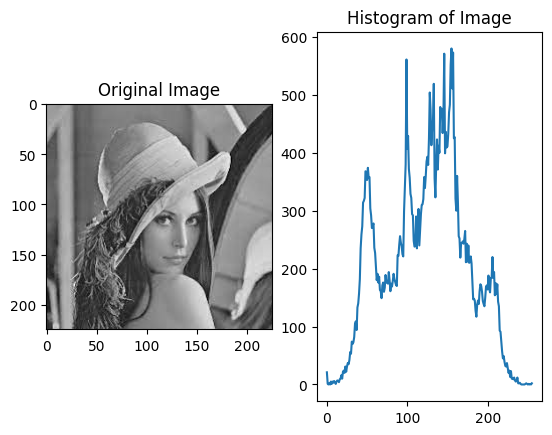

In [39]:
highest_pixel = np.max(image_gray)
L = np.ceil(np.log2(highest_pixel))
two_to_the_power_l = 2**L
hist = np.zeros(int(two_to_the_power_l))

for i in range(height):
    for j in range(width):
        pixel = image_gray[i,j]
        hist[pixel]+=1


plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image_gray, cmap='gray')

plt.subplot(1,2,2)
plt.title("Histogram of Image")
plt.plot(hist)

plt.show()

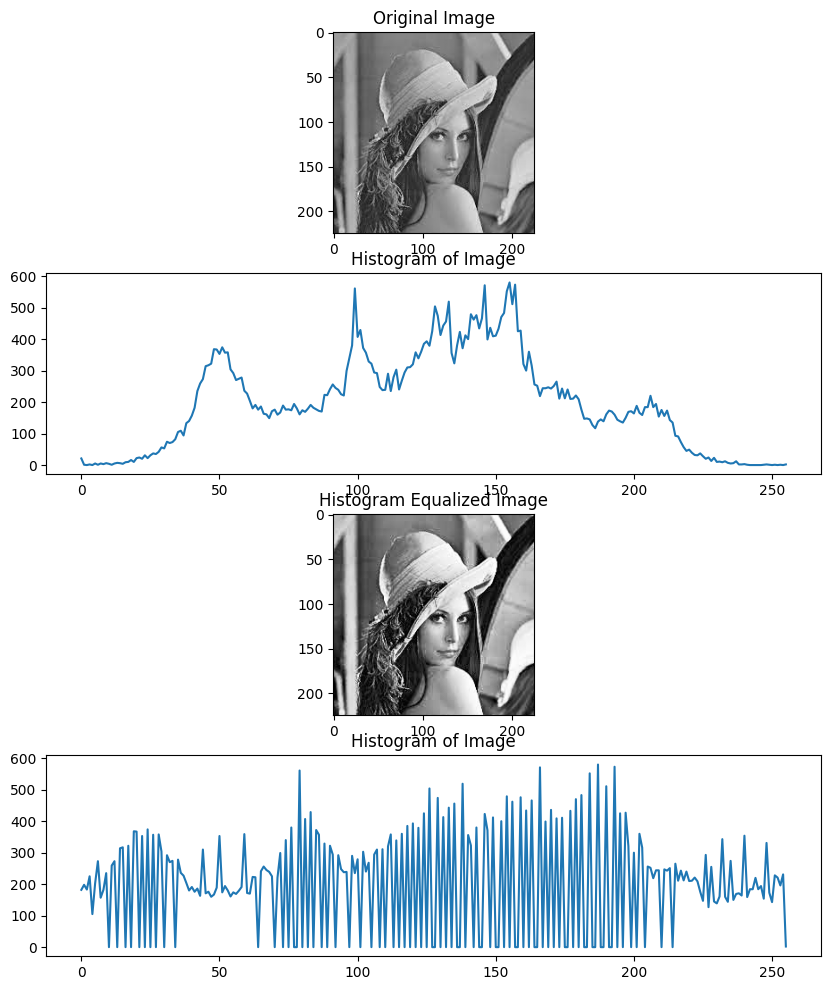

In [57]:
highest_pixel = np.max(image_gray)
L = np.ceil(np.log2(highest_pixel))

two_to_the_power_l = 2**L
hist = np.zeros(int(two_to_the_power_l))

for i in range(height):
    for j in range(width):
        pixel = image_gray[i,j]
        hist[pixel]+=1

total_pixels = width*height
pdf = []
for i in hist:
    pdf.append(i/total_pixels)

cdf = []
for index,i in enumerate(pdf):
    if index ==0:
        cdf.append(pdf[0])
        continue
    cdf.append( pdf[index]+cdf[index-1] )

normalized_cdf = []
for i in cdf:
    normalized_cdf.append(int(i*(two_to_the_power_l-1)))

equalized = np.zeros((height,width),dtype=np.uint8)
for i in range(height):
    for j in range(width):
        equalized[i,j] = normalized_cdf[image_gray[i,j]]


hist_eq = np.zeros(256)

for i in range(height):
    for j in range(width):
        pixel = equalized[i, j]
        hist_eq[pixel] += 1

plt.figure(figsize=(10, 12))

plt.subplot(4,1,1)
plt.title("Original Image")
plt.imshow(image_gray, cmap='gray')

plt.subplot(4,1,2)
plt.title("Histogram of Image")
plt.plot(hist)

plt.subplot(4,1,3)
plt.title("Histogram Equalized Image")
plt.imshow(equalized, cmap='gray')

plt.subplot(4,1,4)
plt.title("Histogram of Image")
plt.plot(hist_eq)

plt.show()